FileNotFoundError: [Errno 2] No such file or directory: './result-ext/mil-contrast.svg'

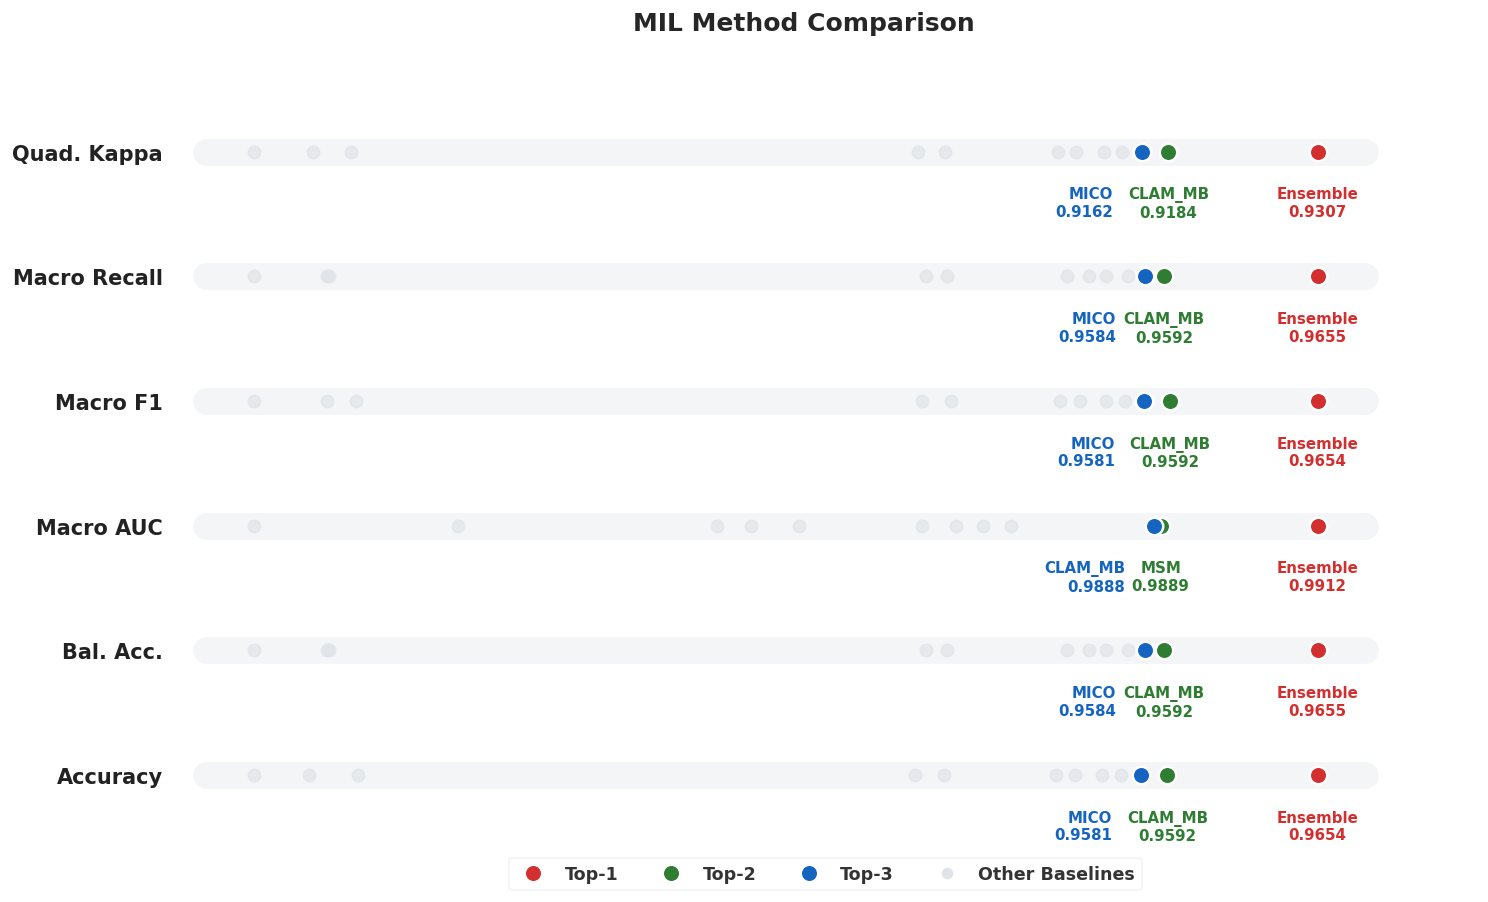

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


def parse_stat(text):
    if pd.isna(text): return 0.0
    if isinstance(text, (int, float)): return float(text)
    try:
        return float(re.split('±', str(text))[0])
    except:
        return 0.0


df = pd.read_csv('External/all_metrics_summary.csv')

target_method = 'Ensemble'
methods_list = ['AB_MIL', 'TRANS_MIL', 'CLAM_MB_MIL', 'CLAM_SB_MIL', 'WIKG_MIL',
                'MAMBA2D_MIL', 'AEM_MIL', 'MICO_MIL', 'MSM_MIL', 'TDA_MIL', 'GDF_MIL', 'Ensemble']
df = df[df['method'].isin(methods_list)].reset_index(drop=True)

perf_metrics = ['acc', 'bacc', 'macro_auc', 'macro_f1', 'macro_recall', 'quadratic_kappa']
metrics_map = {
    'acc': 'Accuracy', 'bacc': 'Bal. Acc.', 'macro_auc': 'Macro AUC',
    'macro_f1': 'Macro F1', 'macro_recall': 'Macro Recall', 'quadratic_kappa': 'Quad. Kappa'
}

colors = {
    'top1': '#D32F2F', 'top2': '#2E7D32', 'top3': '#1565C0',
    'target_out': '#5E35B1',  # 跌出前三时高亮深紫色
    'others': '#E0E4E8', 'range': '#F4F5F7'
}

fig, ax = plt.subplots(figsize=(14, 8.5), dpi=120)
sns.set_style("white")

for i, m in enumerate(perf_metrics):
    temp_df = df[['method', m]].copy()
    temp_df['val'] = temp_df[m].apply(parse_stat)

    # 严格绝对排序
    sorted_df = temp_df.sort_values('val', ascending=False).reset_index(drop=True)

    # 归一化 X 坐标映射
    v_min, v_max = sorted_df['val'].min(), sorted_df['val'].max()
    denom = (v_max - v_min) if (v_max - v_min) > 1e-9 else 1e-9
    sorted_df['plot_x'] = 0.18 + (sorted_df['val'] - v_min) / denom * 0.67

    ax.hlines(y=i, xmin=0.15, xmax=0.88, color=colors['range'], linewidth=16, zorder=1, capstyle='round')

    top3_df = sorted_df.iloc[:3]
    others_df = sorted_df.iloc[3:]

    target_in_top3 = target_method in top3_df['method'].values

    if not target_in_top3:
        target_row = others_df[others_df['method'] == target_method]
        others_df = others_df[others_df['method'] != target_method]

    ax.scatter(others_df['plot_x'], [i] * len(others_df), color=colors['others'], s=55, alpha=0.7, zorder=2)

    plot_queue = []
    for rank, (_, row) in enumerate(top3_df.iterrows()):
        plot_queue.append((f'top{rank + 1}', row))

    if not target_in_top3 and not target_row.empty:
        plot_queue.append(('target_out', target_row.iloc[0]))

    occupied_x = []

    for style_key, row in plot_queue:
        px = row['plot_x']
        val = row['val']
        name = row['method'].replace('_MIL', '')
        is_target = (row['method'] == target_method)

        ax.scatter(px, i, color=colors[style_key], s=110, edgecolors='white', linewidths=1.5, zorder=4)

        ha_style = 'center'
        text_x = px

        # 遍历检查是否与已有的文字标签 X 轴冲突
        for past_x in occupied_x:
            if abs(px - past_x) < 0.05:
                # 如果当前点在已有点的左侧，文字继续往左挪并右对齐；反之亦然
                if px < past_x:
                    text_x = px - 0.018
                    ha_style = 'right'
                else:
                    text_x = px + 0.018
                    ha_style = 'left'
                break

        occupied_x.append(text_x)

        font_w = 'bold' if is_target else 'semibold'
        ax.text(text_x, i - 0.28, f"{name}\n{val:.4f}", color=colors[style_key],
                ha=ha_style, va='top', fontsize=9, fontweight=font_w,
                bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.85))

ax.set_yticks(range(len(perf_metrics)))
ax.set_yticklabels([metrics_map[m] for m in perf_metrics], fontsize=12.5, fontweight='bold', color='#222222')
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(left=False)
sns.despine(left=True, bottom=True)

ax.set_ylim(-0.5, len(perf_metrics) - 0.2)
ax.set_xlim(0.13, 0.95)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['top1'], markersize=10, label='Top-1'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['top2'], markersize=10, label='Top-2'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['top3'], markersize=10, label='Top-3'),
    # Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['target_out'], markersize=10, label=f'{target_method} (Out of Top-3)'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['others'], markersize=8, label='Other Baselines')
]

leg = ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.015),
                ncol=5, frameon=True, fontsize=10.5, edgecolor='#F0F0F0', facecolor='white')
leg.get_frame().set_linewidth(1.0)
for text in leg.get_texts():
    text.set_color("#333333")
    text.set_weight("semibold")

plt.suptitle('MIL Method Comparison', fontsize=15, fontweight='bold', x=0.5, y=0.92)
plt.savefig('./result-ext/mil-contrast.svg', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_refined_white_bg_matrix(df, output_path='final_combined_cm_blue.pdf'):
    centers, types = ['301', 'YNZL', 'SL', 'Total'], ['CNB', 'TURP', 'RP', 'total']

    # 强制背景为白色
    sns.set_style("white")
    fig, axes = plt.subplots(4, 4, figsize=(12, 11), sharex=True, sharey=True)
    fig.patch.set_facecolor('white')

    # 子图间距设为 0.05，既紧凑又有黑色边框隔断感
    plt.subplots_adjust(wspace=0.05, hspace=0.05)

    for r, t in enumerate(types):
        for c, center in enumerate(centers):
            ax = axes[r, c]
            ax.set_facecolor('white')

            sub = df.copy()
            if center != 'Total': sub = sub[sub['center'] == center]
            if t != 'total': sub = sub[sub['type'] == t]

            if sub.empty:
                # 空数据也画黑框，保持对齐
                for spine in ax.spines.values():
                    spine.set_visible(True); spine.set_linewidth(1.2); spine.set_color('black')
                continue

            cm = confusion_matrix(sub['test_label'], sub['prediction'], labels=[0, 1])
            cm_norm = confusion_matrix(sub['test_label'], sub['prediction'], labels=[0, 1], normalize='true')

            # 蓝白色系
            sns.heatmap(cm_norm, annot=False, cmap='Blues', cbar=False, ax=ax,
                        linewidths=1, linecolor='white', vmin=0, vmax=1)

            # 填充文本逻辑：动态黑白字
            for i in range(2):
                for j in range(2):
                    # 只有当颜色深到一定程度（>0.5）才用白字
                    text_color = "white" if cm_norm[i, j] > 0.5 else "black"
                    ax.text(j+0.5, i+0.5, f"{cm_norm[i,j]:.1%}\n(n={cm[i,j]})",
                            ha="center", va="center", color=text_color, fontsize=9, fontweight='medium')

            # 处理坐标轴标注：只保留最左和最下
            if r == 3:
                ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=10, color='black')
            if c == 0:
                ax.set_yticklabels(['True 0', 'True 1'], fontsize=10, rotation=0, color='black')
                ax.set_ylabel(t, fontweight='bold', fontsize=12, color='black')

            # 第一行显示中心名称
            if r == 0: ax.set_title(center, fontweight='bold', fontsize=13, pad=10, color='black')

            # 关键：每个子图强制黑色外框
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.2)
                spine.set_color('black')

    plt.suptitle("Confusion Matrix Analysis (Multi-center & Multi-type)", fontsize=16, y=0.98, color='black')

    # 保存为 PDF
    plt.savefig(output_path, bbox_inches='tight', format='pdf', facecolor='white')
    plt.show()


# 调用
df = pd.read_csv('infer/Contrast/External/Ensemble/merged_ensemble_results.csv')
plot_refined_white_bg_matrix(df)